# K-means on synthetic data
## Step 1 - generating a synthetic dataset

## Initializing the centroids

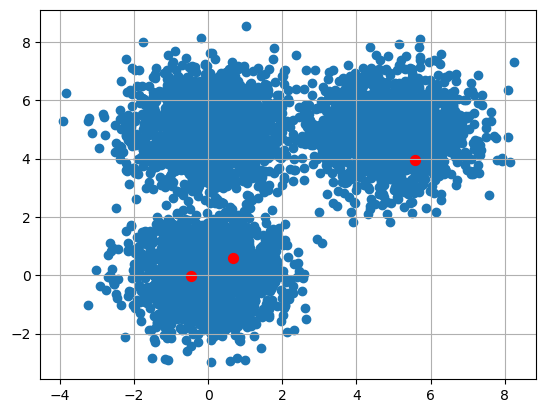

In [3]:
k = 3
centroids = []

for i in range(k):
    centroid = X[np.random.choice(X.shape[0])]
    centroids.append(centroid)

centroids = np.array(centroids)
centroids
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(centroids[:, 0], centroids[:, 1],
            color='red', marker='.', s=200)

plt.grid(True)
plt.show()


## Define labels - distance from centroids for each point

In [4]:
def get_labels(X, centroids):
    distances = []
    
    for centroid in centroids:
        dist = np.sqrt(np.sum((X - centroid)**2, axis=1))
        distances.append(dist)
    
    distances = np.array(distances).T
    
    return np.argmin(distances, axis=1)

In [5]:
labels = get_labels(X,centroids)
counts = np.bincount(labels)

for i, count in enumerate(counts):
    print(f"Cluster {i}: {count} points")

Cluster 0: 1924 points
Cluster 1: 2059 points
Cluster 2: 1015 points


## Update the centroids

In [6]:
def new_centroids(X, labels, k):
    centroids = []
    
    for i in range(k):
        points = X[labels == i]
        
        if len(points) == 0:
            centroid = X[np.random.randint(0, X.shape[0])]
        else:
            centroid = points.mean(axis=0)  
            
        centroids.append(centroid)   
        
    return np.array(centroids)

In [7]:
def random_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

In [8]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [9]:
def plot_clusters(X, labels, centroids, iteration):
    clear_output(wait=True)
    
    plt.title(f"Iteration {iteration}")
    
    plt.scatter(X[:, 0], X[:, 1], c=labels, alpha=0.6)
    
    plt.scatter(centroids[:, 0], centroids[:, 1],
                color='red', marker='.', s=200)
    
    plt.grid(True)
    plt.show()

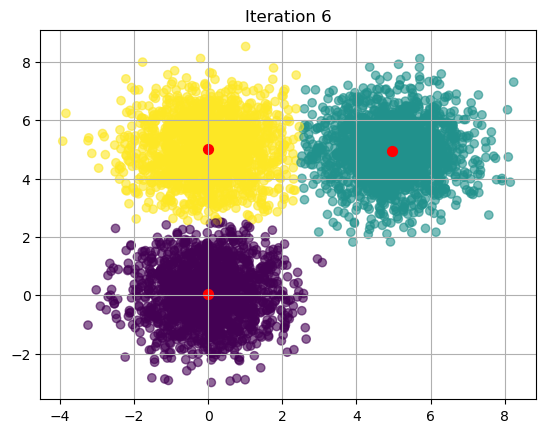

Converged at iteration 6


In [3]:
max_iterations = 100
k = 3

centroids = random_centroids(X, k)
iteration = 0

for iteration in range(max_iterations):
    
    old_centroids = centroids.copy()
    
    labels = get_labels(X, centroids)
    centroids = new_centroids(X, labels, k)
    
    plot_clusters(X, labels, centroids, iteration)
    
    if np.allclose(centroids, old_centroids):
        print(f"Converged at iteration {iteration}")
        break

## calculating inertia and variance

In [5]:
def compute_inertia(X, labels, centroids):
    inertia = 0
    
    for i in range(len(X)):
        centroid = centroids[labels[i]]
        inertia += np.sum((X[i] - centroid) ** 2)
    
    return inertia

In [6]:
inertia = compute_inertia(X, labels, centroids)
print(inertia)

9885.09885840983


# **New start**

## Synthetic data

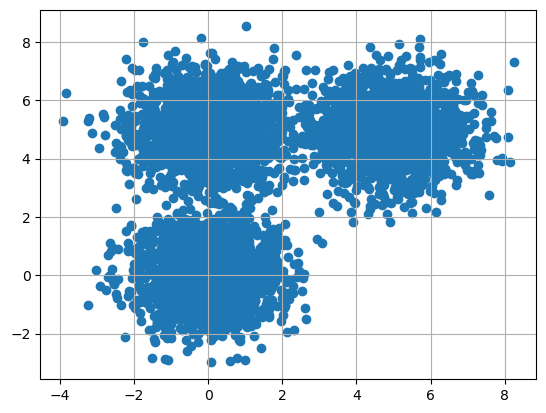

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(42)

n = 5000

# cluster sizes
n1 = n2 = n3 = n // 3

# define means manually
mean1 = [0, 0]
mean2 = [5, 5]
mean3 = [0, 5]

# generate clusters
c1 = np.random.randn(n1, 2) + mean1
c2 = np.random.randn(n2, 2) + mean2
c3 = np.random.randn(n3, 2) + mean3

X_synth = np.vstack((c1, c2, c3))

plt.scatter(X_synth[:, 0], X_synth[:, 1])
plt.grid(True)
plt.show()

## Real world data - MNIST dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version = 1)

X = mnist.data.to_numpy()
X = X / 255.0 #normalizing the data
y = mnist.target.astype(int).to_numpy()

#subsetting mnist to work with a more manageable size

subset_size = 5000
indices = np.random.choice(X.shape[0], subset_size, replace=False)

X_subset = X[indices]
y_subset = y[indices]
X = X_subset
y = y_subset

print(X.shape)
print(y.shape)

(5000, 784)
(5000,)


## kmeans function

In [3]:
# helper functions

def random_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def get_labels(X, centroids):
    distances = []

    for centroid in centroids:
        dist = np.sqrt(np.sum((X - centroid) ** 2, axis=1))
        distances.append(dist)

    distances = np.array(distances).T

    return np.argmin(distances, axis=1)

def new_centroids(X, labels, k):
    centroids = []

    for i in range(k):
        points = X[labels == i]

        if len(points) == 0:
            centroid = X[np.random.randint(0, X.shape[0])]
        else:
            centroid = points.mean(axis=0)

        centroids.append(centroid)

    return np.array(centroids)

#kmeans final function

def kmeans(X, k, max_rounds=100):

    centroids = random_centroids(X, k)

    for iteration in range(max_rounds):

        old_centroids = centroids.copy()

        labels = get_labels(X, centroids)

        centroids = new_centroids(X, labels, k)

        if np.allclose(centroids, old_centroids):
            break

    return labels, centroids

## Example of kmeans results

ValueError: cannot reshape array of size 2 into shape (28,28)

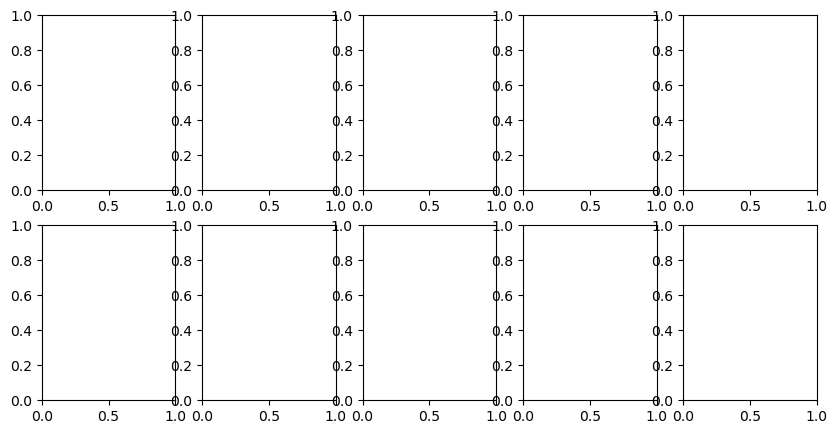

In [17]:
labels, centroids = kmeans(X, 10)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(centroids[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Cluster {i}")
    ax.axis('off')

plt.show()

inertia = compute_inertia(X, labels, centroids)
print(intertia)

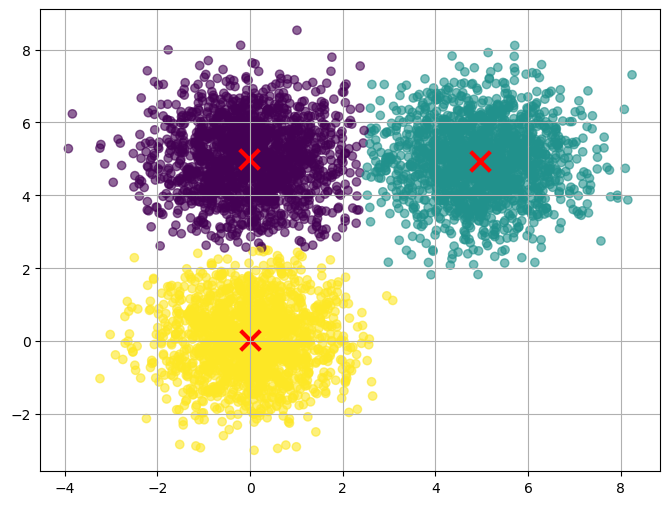

9885.09885840983


In [16]:
labels, centroids = kmeans(X_synth, 3)

plt.figure(figsize=(8, 6))

# plot data points
plt.scatter(
    X_synth[:, 0],
    X_synth[:, 1],
    c=labels,
    alpha=0.6
)

# plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    color='red',
    marker='x',
    s=200,
    linewidths=3
)

plt.grid(True)

plt.show()

inertia_synth = compute_inertia(X_synth, labels, centroids)
print(inertia_synth)

## Calculating inertia

In [14]:
def compute_inertia(X, labels, centroids):
    inertia = 0
    
    for i in range(len(X)):
        centroid = centroids[labels[i]]
        inertia += np.sum((X[i] - centroid) ** 2)
    
    return inertia

In [15]:
inertia = compute_inertia(X, labels, centroids)
inertia_synth = compute_inertia(X_synth, labels, centroids)
print(inertia)
print(inertia_synth)

9885.09885840983
9885.09885840983
